*Do not delete this style setting*

In [1]:
%%html
<style>
table {float:left}
</style>

# Session 2: <font color="red">Challenge D - Swiss Roll</font><br>A Simple Quantum Estimator

<table>
    <tr><td><strong>Aim:</strong></td>
        <td>To explore the creation and use of a simple quantum estimator in <strong>PennyLane</strong><br>
            Note that "simplicity" is only in data and the model structure - not in the approach!</td></tr>
    <tr><td><strong>Author:</strong></td>
        <td>Jacob L. Cybulski (<a href="https://jacobcybulski.com/" target="_blank">website</a>),
            <em>Enquanted</em></td></tr>
    <tr><td><strong>Release:</strong></td>
        <td>April 2025</td></tr>
    <tr><td><strong>Updated:</strong></td>
        <td>October 2026</td></tr>
    <tr><td><strong>Datasets:</strong></td>
        <td>We will use the following two data set generators from sklearn (code below):<br>
            <ol><li>from sklearn.datasets import <strong><em>make_regression</em></strong> (Workshop)</li>
                <li>from sklearn.datasets import <strong><em>make_swiss_roll</em></strong> or <br>
                    from UCI repository download <strong><em><a href="https://archive.ics.uci.edu/dataset/477/real+estate+valuation+data+set" target="_blank">Real Estate Valuations</a></em></strong> dataset<br>(requires: ucimlrepo)</li>
            </ol></td></tr>
    <tr><td><strong>Tasks:</strong></td>
        <td>40 minutes (unfinished tasks go to self-directed "challenges")</td></tr>
    <tr>
        <td></td>
        <td>Perform the following tasks<br>(record your observations at end of this notebook):<br><ol>
            <li>Initially use the <strong><em>Regression</em></strong> dataset 1 (as provided).<br>
                Follow the instructor demonstration to step through the code.<br>
                - consider changing qubit type and diff-method to reduce training time.</li>
            <li>Can you improve the selected model by:<br>
                - changing entangling methods (basic_ent = False/True) ?<br>
                - changing the number of qubits/wires ?<br>
                - changing the number of training epochs ?<br>
                - changing the optimiser ?<br>
                Which of these changes had the greatest impact on performance?</li>
            <li>Change data encoding by increasing the encoding margin.<br>
                What was the impact of your change? Why do you think it happened ?</li>
            <li>Calculate testing MSE and R2 scores.<br>
                Follow the example of calculating training R2.</li>
            <li>Create a plot of residuals for training and test predictions.<br>
                Note that residuals are (expected-predicted) values.</li>
            <li>Test if global cost (measuring all qubits) could improve
                the result of a model with a local cost (measuring one qubit).<br>
                - Hint calculate a tensor product of Z observables.</li>
            <li>Reflect on this session.</li>
        </ol></td>
    </tr>
    <tr>
        <td><strong>Challenge<br>Tasks:</strong></td>
        <td>Perform the following tasks in your own time:<br/>
        <ol style="list-style-type: upper-alpha;">
            <li>Complete the unfinished tasks.</li>
            <li>Change the model by incorporating the reuploading ansatz (see Session 1).</li>
            <li>Create a more insightful visualisation of residuals (research).</li>
            <li>Apply your completed model to either of the following data sets:<br>
                <strong><em>Real Estate Valuations</em></strong> or <strong><em>Swiss Roll</em></strong> (data set 2)<br> 
                - see examples at the end of the notebook<br>
            </li>
        </ol>
        </td>
    </tr>
    <tr><td><strong>References:</strong></td>
        <td><a href="https://www.youtube.com/watch?v=42aa-Ve5WmI" target="_blank">
            Catalina Albornoz, "Optimizing a quantum circuit with PennyLane",<br>PennyLane Tutorial, YouTube Video, Sept 12, 2023.</a></td>
    </tr>
    <tr><td><strong>License:</strong></td>
        <td>This project is licensed under the
            <a href="https://www.gnu.org/licenses/gpl-3.0.en.html" target="_blank">GNU General Public License v3</a></td></tr>
    <tr><td><strong>Changes:</strong></td>
        <td>All significant changes to this code must be recorded in this notebook</td></tr>
</table>

## Libraries

In [2]:
import sys
sys.path.append('.')
sys.path.append('..')
sys.path

['/home/jacob/miniconda3/envs/pl-qml-2026/lib/python311.zip',
 '/home/jacob/miniconda3/envs/pl-qml-2026/lib/python3.11',
 '/home/jacob/miniconda3/envs/pl-qml-2026/lib/python3.11/lib-dynload',
 '',
 '/home/jacob/miniconda3/envs/pl-qml-2026/lib/python3.11/site-packages',
 '.',
 '..']

In [3]:
### General libraries

import os
import math
import time
import copy
import numpy as nnp # if wanted to use standard numpy
import pandas as pd
from IPython.display import clear_output

import matplotlib.pyplot as plt
from matplotlib import set_loglevel
set_loglevel("warning")

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

In [4]:
### Import utilities
from utilities import *

In [5]:
### Import PennyLane
import pennylane as qml
from pennylane import numpy as np # redefined numpy
import torch # for Linux with 'lightning-quit' and diff_method='adjoint'

import plotly.express as px
from sklearn.datasets import make_regression
from sklearn.metrics import r2_score, mean_squared_error

---

## <font color="blue">Data preparation</font>

### Data set in its original form

In [6]:
from sklearn.datasets import make_swiss_roll

np.random.seed(42)
data_seed = 42
n_samples = 600 # 1000 # Reduce to 300
n_features = 3
noise = 0.2

X_raw, y_flat = make_swiss_roll(
    n_samples=n_samples,
    noise=0,
    random_state=data_seed,
    hole=False # With the hole it is harder
)
y_raw = y_flat.reshape((y_flat.shape[0], 1))

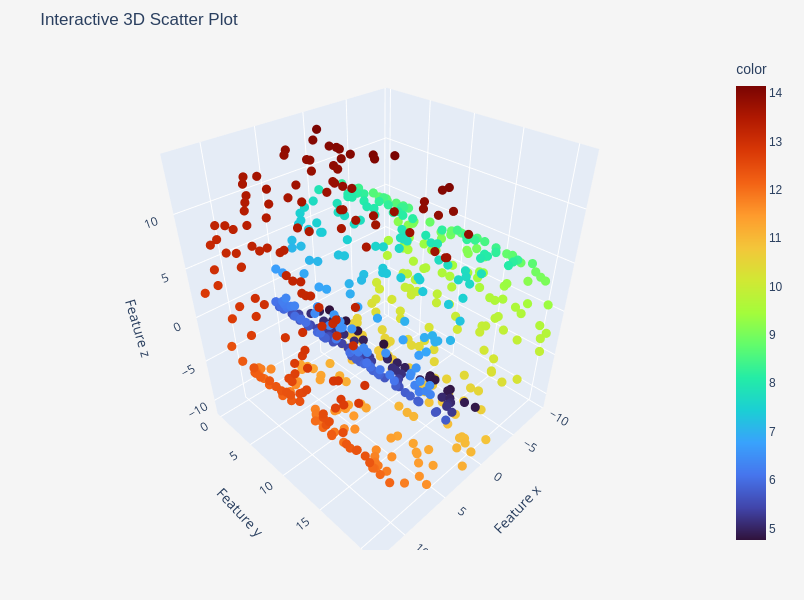

In [7]:
import plotly as ply
import plotly.express as px
import plotly.io as pio
# The following may preserve the chart on saving
# pio.renderers.default = 'jupyterlab' # or 'notebook'

# Create an interactive 3D scatter plot, of the first two columns
fig = px.scatter_3d(x=X_raw[:, 0], y=X_raw[:, 1], z=X_raw[:, 2], 
                    title='Interactive 3D Scatter Plot',
                    labels={'x': 'Feature x', 
                            'y': 'Feature y', 
                            'z': 'Feature z'},
                    color=y_flat, 
                    color_continuous_scale = ply.colors.sequential.Turbo)
mrg = dict(l = 50, r = 50, b = 50, t = 50, pad = 10)
fig.update_traces(marker=dict(size=3, symbol='circle'))
fig.update_layout(width=600, height=600, margin = mrg, paper_bgcolor = 'whitesmoke')
fig.show()

---

## <font color="blue">Model development</font>

### Model and training configuration

In [8]:
### Data params used in scaling
#   Encoded values to be scaled to range (0..pi)
#   Optionally, margins can be left out on the value boundaries
x_angle_margin = 0.5 
x_angle_min = 0+x_angle_margin
x_angle_max = np.pi-x_angle_margin

### Architectural parameters
n_wires = 4 # n_features
n_layers = 5
basic_ent = False
wires = list(range(n_wires))

### Training hyper-parameters
epochs = 100 # 20 # 50 (preferred) # 100 # 300 (long wait)
prompt_fract = 0.05 # Fraction of results shown in training
shots = None # Theoretical results will be computed
seed = 2025

### Prepare data for the quantum estimator

In [9]:
### Standardise X values to the range 0..pi
from sklearn.preprocessing import StandardScaler, MinMaxScaler
X_scaler = MinMaxScaler(feature_range=(x_angle_min, x_angle_max)) 
X_scaled = X_scaler.fit_transform(X_raw)
y_scaler = MinMaxScaler(feature_range=(0.0, 1.0))
y_scaled = y_scaler.fit_transform(y_raw)

In [10]:
### Create data partitions
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, 
                                                    test_size=0.33, random_state=seed, shuffle=False)
print(f'Shapes: X_train={X_train.shape}, X_test={X_test.shape}, y_train={y_train.shape}, y_test={y_test.shape}')

Shapes: X_train=(402, 3), X_test=(198, 3), y_train=(402, 1), y_test=(198, 1)


In [11]:
### Change the data format to tensors
X_train_tens = qml.numpy.tensor(np.array(X_train), requires_grad=False)
y_train_tens = qml.numpy.tensor(np.array(y_train), requires_grad=False)
X_test_tens  = qml.numpy.tensor(np.array(X_test), requires_grad=False)
y_test_tens  = qml.numpy.tensor(np.array(y_test), requires_grad=False)

## Loss and cost function

In [12]:
### Our own gradient-friendly loss function
def mse_cost(targets, predictions):
    cost = 0
    for l, p in zip(targets, predictions):
        cost = cost + (l - p) ** 2
    cost = cost / len(targets)
    return cost

### The cost function generator
def cost_fun_gen(model, cost_fun):
    def _cost_fun(params, inputs, targets):
        nonlocal model, cost_fun
        preds = [model(params, x) for x in inputs]
        return cost_fun(targets, preds)
    return _cost_fun

## PennyLane quantum linear model

In [13]:
### Define default device
sim = 'lightning.qubit' # default.qubit lightning.qubit lightning.gpu
dev = qml.device(sim, wires=n_wires, shots=shots)

print(f'Device to be used:  {sim}\n')

Device to be used:  lightning.qubit



*For the Swiss Roll data set we will need to introduce
some non-linearity into the model - in our case data reuploading, 
which can be triggered via an option.*
*The model also has the flexibility of using either basic or strong qubit entanglement.*

In [14]:
### Define a quantum linear model functionally
### This is the PennyLane style of doing things
def qlinear(n_wires, n_layers=1, scaler=1.0, basic=False, reupload=True):
    
    def _qlinear(weights, inputs):
        nonlocal n_wires, n_layers, scaler, basic, reupload
        data_wires = list(range(n_wires))
        scaled_inputs = inputs * scaler

        qml.AngleEmbedding(scaled_inputs, wires=data_wires)
        for l in range(n_layers):

            # Standard angle encoding block
            if l > 0 and reupload: 
                qml.AngleEmbedding(scaled_inputs, wires=data_wires)  
    
            # Ansatz with optional basic or strong entangling block
            if basic:
                qml.BasicEntanglerLayers(weights[l].reshape((1, *weights[l].shape)), 
                                         wires=data_wires, rotation=qml.RY)
            else:
                qml.StronglyEntanglingLayers(weights[l].reshape((1, *weights[l].shape)), 
                                             wires=data_wires)
            
        return qml.expval(qml.PauliZ(0))
        
    return _qlinear

In [15]:
### Check the model shape
### This is defined so that we could select and check the shape in one place
def qlinear_shape(n_wires, n_layers=1, basic=False):
    if basic:
        shape = qml.BasicEntanglerLayers.shape(n_layers=n_layers, n_wires=n_wires)
    else:
        shape = qml.StronglyEntanglingLayers.shape(n_layers=n_layers, n_wires=n_wires)
    return shape

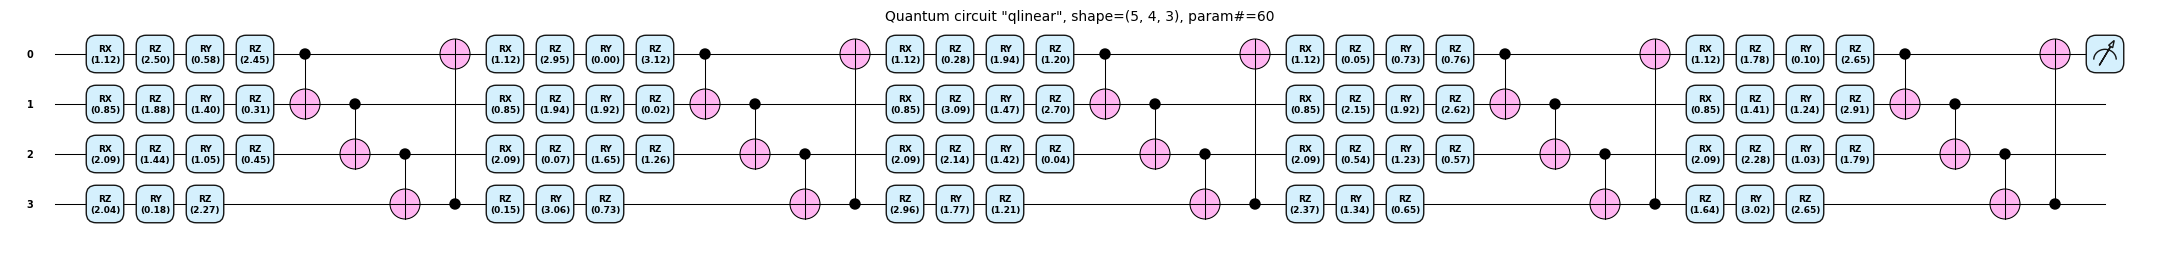

In [16]:
### Create a quantum linear model

# Prepare the quantum linear model and then its qnode (circuit)
qmodel = qlinear(n_wires, n_layers=n_layers, basic=basic_ent, reupload=True)
qlinear_model = qml.QNode(qmodel, device=dev, diff_method='adjoint')
shape = qlinear_shape(n_wires, n_layers=n_layers, basic=basic_ent)

# Plot the model circuit (needs weights and some input)
test_params = np.random.uniform(high=np.pi, size=shape, requires_grad=True)
draw_circuit(qlinear_model, scale=0.5, 
             title=f'Quantum circuit "qlinear", shape={shape}, param#={np.prod(shape)}', level='device') \
    (test_params, X_train_tens[0]) # level='device'/'gradient'

In [17]:
### Test the model
print(f'\nQM weights: {np.prod(shape)}, Epochs: {epochs}')
print(f'\nTest results: {qlinear_model(test_params, X_train_tens[0:5])}\n')


QM weights: 60, Epochs: 100

Test results: [ 0.02977845  0.27031616 -0.13307329 -0.36671336 -0.348523  ]



## Creation and training of the linear model

In [18]:
### Set the random seed
np.random.seed(seed)

### Select one of the following optimisers built into PennyLane
# opt = qml.GradientDescentOptimizer(stepsize=0.5)
# opt = qml.RMSPropOptimizer(stepsize=0.1, decay=0.7, eps=1e-08)
# opt = qml.NesterovMomentumOptimizer(stepsize=0.5)
# opt = RCDOptimizer(h=0.1)
opt = qml.AdamOptimizer(stepsize=0.2)

### Define the cost function
cost_fun = cost_fun_gen(qlinear_model, mse_cost)

### Initialise the model weights / parameters
params = np.random.uniform(high=np.pi, size=shape, requires_grad=True)

### Training loop
hist_cost = []
hist_params = []
prompt_fract = 0.1
start_time = time.time() 
for iter in range(epochs):
    params, cost = opt.step_and_cost(lambda p: cost_fun(p, X_train_tens, y_train_tens), params)
    hist_cost.append(cost.item())
    hist_params.append(params)
    elapsed_time = time.time()-start_time
    if (prompt_fract == 0) or (iter % int(prompt_fract*epochs) == 0):
        print(f'Iter: {iter:03d} ({int(elapsed_time):03d} sec) cost={np.round(cost, 6)}')

### Print the training summary
train_mse_hist = hist_cost
train_min_mse = np.min(train_mse_hist)
train_min_mse_iter = np.argmin(train_mse_hist)
print(f'\nTraining completed: epochs={epochs}, '+\
      f'min cost={np.round(train_min_mse, 6)} @ {train_min_mse_iter}, '+\
      f'time={int(elapsed_time):03d} secs\n')

Iter: 000 (003 sec) cost=[0.441049]
Iter: 010 (035 sec) cost=[0.064117]
Iter: 020 (063 sec) cost=[0.03094]
Iter: 030 (094 sec) cost=[0.015655]
Iter: 040 (122 sec) cost=[0.010581]
Iter: 050 (150 sec) cost=[0.008092]
Iter: 060 (177 sec) cost=[0.006929]
Iter: 070 (205 sec) cost=[0.006172]
Iter: 080 (232 sec) cost=[0.005436]
Iter: 090 (259 sec) cost=[0.004845]

Training completed: epochs=100, min cost=0.004435 @ 99, time=287 secs



## Calculate optimum scores

*Calculate training R2 scores.*

In [19]:
### Calculate training R2
train_r2_hist = []
train_max_r2 = -float(np.inf)
train_max_r2_iter = -1

# Accumulate R2 scores
print()
for iter in range(len(hist_params)):
    iter_params = hist_params[iter]
    train_pred = qlinear_model(iter_params, X_train_tens)
    curr_r2 = r2_score(y_train_tens, train_pred)
    train_r2_hist.append(float(curr_r2))
    if curr_r2 > train_max_r2:
        test_max_r2 = curr_r2
        test_max_r2_iter = iter
    if (prompt_fract == 0) or (iter % int(prompt_fract*epochs) == 0):
        print(f'Iter#: {iter:3d} / {epochs:3d}, '+
              f'MSE train: {train_mse_hist[iter]:.6f}, R2 train: {curr_r2:.6f}')

# Find the optimum training loss and R2
train_max_r2 = np.max(train_r2_hist)
train_max_r2_iter = np.argmax(train_r2_hist)

# Show training results
print(f'\nTraining results: MSE = {train_min_mse:.6f} @ {train_min_mse_iter:04d}, '+
      f'R2 = {train_max_r2:.6f} @ {train_max_r2_iter:04d}\n')


Iter#:   0 / 100, MSE train: 0.441049, R2 train: -1.191173
Iter#:  10 / 100, MSE train: 0.064117, R2 train: 0.246504
Iter#:  20 / 100, MSE train: 0.030940, R2 train: 0.682750
Iter#:  30 / 100, MSE train: 0.015655, R2 train: 0.820724
Iter#:  40 / 100, MSE train: 0.010581, R2 train: 0.883205
Iter#:  50 / 100, MSE train: 0.008092, R2 train: 0.909831
Iter#:  60 / 100, MSE train: 0.006929, R2 train: 0.921495
Iter#:  70 / 100, MSE train: 0.006172, R2 train: 0.930206
Iter#:  80 / 100, MSE train: 0.005436, R2 train: 0.938611
Iter#:  90 / 100, MSE train: 0.004845, R2 train: 0.945119

Training results: MSE = 0.004435 @ 0099, R2 = 0.949684 @ 0099



*Calculate testing MSE and R2 scores.*

In [20]:
### Calculate testing MSE and R2

# Prepare test scores
test_mse_hist = []
test_r2_hist = []

# Initialise testing loss and R2
test_min_mse = float(np.inf)
test_min_mse_iter = -1
test_max_r2 = -float(np.inf)
test_max_r2_iter = -1

# Calculate testing loss and R2
for iter in range(len(hist_params)):
    iter_params = hist_params[iter]
    test_pred = qlinear_model(iter_params, X_test_tens)
    curr_r2 = r2_score(y_test_tens, test_pred)
    curr_mse = mean_squared_error(y_test_tens, test_pred)
    test_r2_hist.append(curr_r2)
    test_mse_hist.append(curr_mse)
    if curr_r2 > test_max_r2:
        test_max_r2 = curr_r2
        test_max_r2_iter = iter
    if curr_mse < test_min_mse:
        test_min_mse = curr_mse
        test_min_mse_iter = iter
    if (prompt_fract == 0) or (iter % int(prompt_fract*epochs) == 0):
        print(f'Iter#: {iter:3d} / {epochs:3d}, '+
              f'MSE test: {test_mse_hist[iter]:.6f}, R2 test: {curr_r2:.6f}')

# Show test results
print(f'\nTesting results:  MSE = {test_min_mse:.6f} @ {test_min_mse_iter:04d}, '+
      f'R2 = {test_max_r2:.6f} @ {test_max_r2_iter:04d}\n')

Iter#:   0 / 100, MSE test: 0.197973, R2 test: -1.099317
Iter#:  10 / 100, MSE test: 0.089617, R2 test: 0.049695
Iter#:  20 / 100, MSE test: 0.039953, R2 test: 0.576337
Iter#:  30 / 100, MSE test: 0.021953, R2 test: 0.767211
Iter#:  40 / 100, MSE test: 0.015591, R2 test: 0.834676
Iter#:  50 / 100, MSE test: 0.014227, R2 test: 0.849132
Iter#:  60 / 100, MSE test: 0.012299, R2 test: 0.869580
Iter#:  70 / 100, MSE test: 0.010593, R2 test: 0.887671
Iter#:  80 / 100, MSE test: 0.009711, R2 test: 0.897029
Iter#:  90 / 100, MSE test: 0.009190, R2 test: 0.902549

Testing results:  MSE = 0.009104 @ 0092, R2 = 0.903456 @ 0092



## Plot costs and scores

### Plot MSE performance

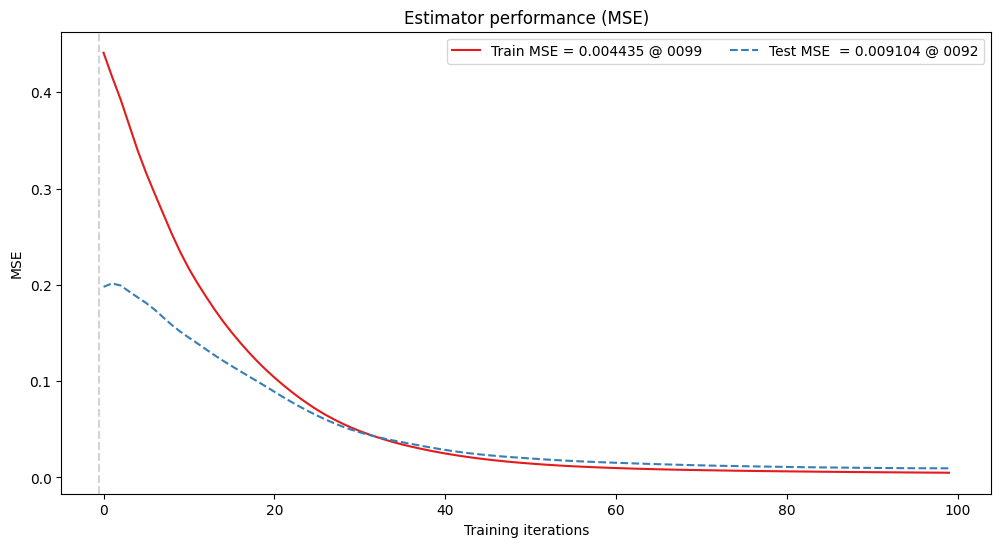

In [21]:
train_label = f'Train MSE = {train_min_mse:.6f} @ {train_min_mse_iter:04d}'
test_label  = f'Test MSE  = {test_min_mse:.6f} @ {test_min_mse_iter:04d}'

multi_plot_series(
    [train_mse_hist, test_mse_hist], X_list=[0, 0], labels=[train_label, test_label], 
    lines=['solid', 'dashed'], # colors=None, markers=None, marker_colors=None,
    rcParams=(12, 6), xlabel='Training iterations', ylabel='MSE',
    legend_cols=2, smooth_weight=0.9, title='Estimator performance (MSE)'
)

### Plot R2 performance

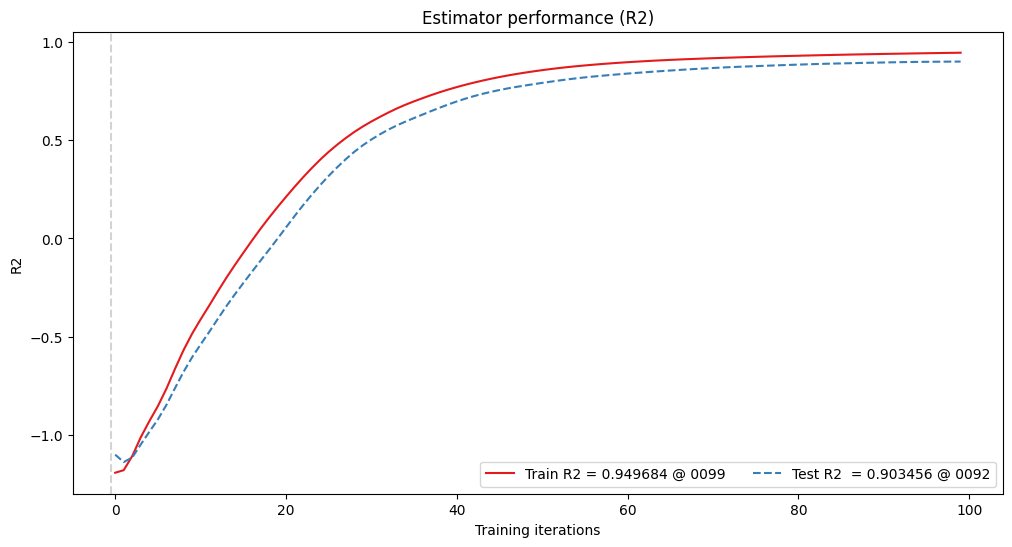

In [22]:
### Plot R2 trainnig and testing scores
train_label = f'Train R2 = {train_max_r2:.6f} @ {train_max_r2_iter:04d}'
test_label  = f'Test R2  = {test_max_r2:.6f} @ {test_max_r2_iter:04d}'

multi_plot_series(
    [train_r2_hist, test_r2_hist], X_list=[0, 0], labels=[train_label, test_label], 
    lines=['solid', 'dashed'], # colors=None, markers=None, marker_colors=None,
    rcParams=(12, 6), xlabel='Training iterations', ylabel='R2',
    legend_cols=2, smooth_weight=0.9, title='Estimator performance (R2)'
)

### Plot residuals of the expected vs predicted data

In [23]:
### Calculate residuals in the original units (dz=expected-predicted)

# Find the predictions for training and test data
opt_test_params = hist_params[test_min_mse_iter]
y_pred_ts = qlinear_model(opt_test_params, X_test)
y_pred_tr = qlinear_model(opt_test_params, X_train)

# Rescale all data to the original units
y_pred_org_ts = y_scaler.inverse_transform(y_pred_ts.reshape((y_pred_ts.shape[0], 1)))
y_true_org_ts = y_scaler.inverse_transform(y_test.reshape((y_test.shape[0], 1)))
z_ts, zt_ts = y_pred_org_ts.reshape((y_pred_org_ts.shape[0])), y_true_org_ts.reshape((y_true_org_ts.shape[0]))
y_pred_org_tr = y_scaler.inverse_transform(y_pred_tr.reshape((y_pred_tr.shape[0], 1)))
y_true_org_tr = y_scaler.inverse_transform(y_train.reshape((y_train.shape[0], 1)))
z_tr, zt_tr = y_pred_org_tr.reshape((y_pred_org_tr.shape[0])), y_true_org_tr.reshape((y_true_org_tr.shape[0]))

# Calculate residuals (true-predicted) normalised to the range of values 
z_range = np.max([np.abs(np.min(zt_ts)), np.abs(np.max(zt_ts)), np.abs(np.min(zt_tr)), np.abs(np.max(zt_tr))])
dz_ts = (zt_ts-z_ts)*100 / z_range
dz_tr = (zt_tr-z_tr)*100 / z_range

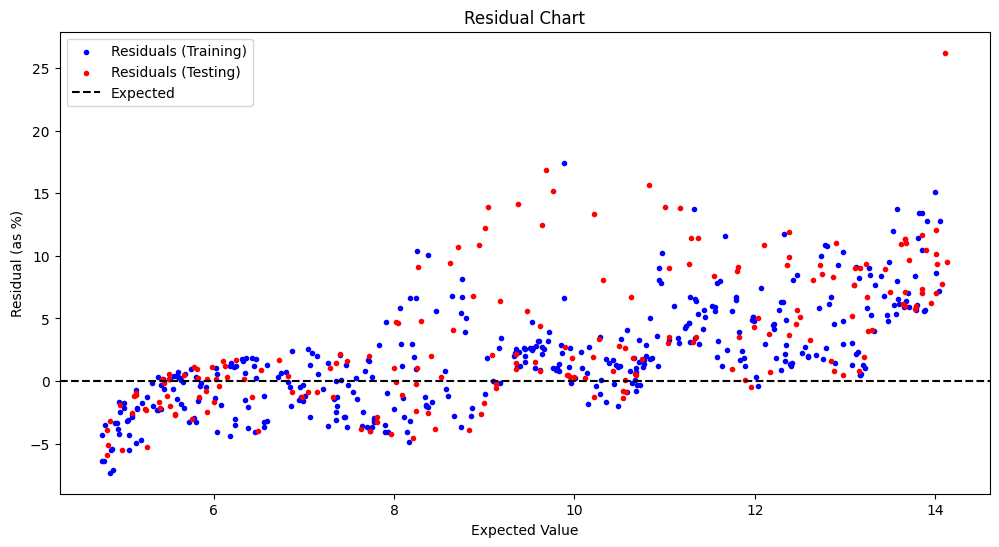

In [24]:
### Plot residuals
plt.title('Residual Chart')
plt.xlabel('Expected Value')
plt.ylabel('Residual (as %)')
plt.scatter(x=zt_tr, y=dz_tr, marker='.', color='blue', label='Residuals (Training)')
plt.scatter(x=zt_ts, y=dz_ts, marker='.', color='red', label='Residuals (Testing)')
plt.axhline(0, linestyle='--', color='black', label='Expected')
plt.legend(loc='best', ncol=1)
plt.show()

---

## Plot prediction

In [25]:
X_org_tr = X_scaler.inverse_transform(X_train)
X_org_ts = X_scaler.inverse_transform(X_test)
y_pred_org_tr_flat = y_pred_org_tr.reshape((y_pred_org_tr.shape[0],))
y_pred_org_ts_flat = y_pred_org_ts.reshape((y_pred_org_ts.shape[0],))

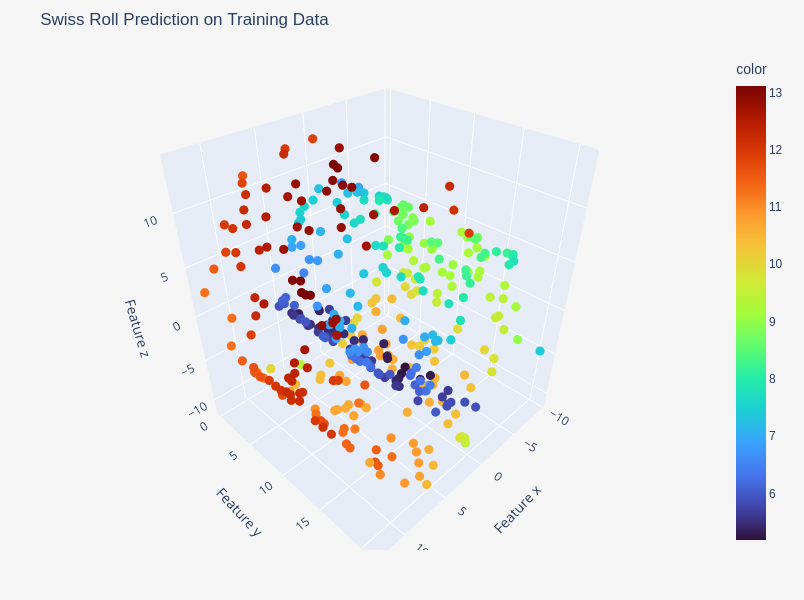

In [26]:
# Create an interactive 3D scatter plot, of the first two columns
fig = px.scatter_3d(x=X_org_tr[:, 0], y=X_org_tr[:, 1], z=X_org_tr[:, 2], 
                    title='Swiss Roll Prediction on Training Data',
                    labels={'x': 'Feature x', 
                            'y': 'Feature y', 
                            'z': 'Feature z'},
                    color=y_pred_org_tr_flat, 
                    color_continuous_scale = ply.colors.sequential.Turbo)
mrg = dict(l = 50, r = 50, b = 50, t = 50, pad = 10)
fig.update_traces(marker=dict(size=3, symbol='circle'))
fig.update_layout(width=600, height=600, margin = mrg, paper_bgcolor = 'whitesmoke')
fig.show()

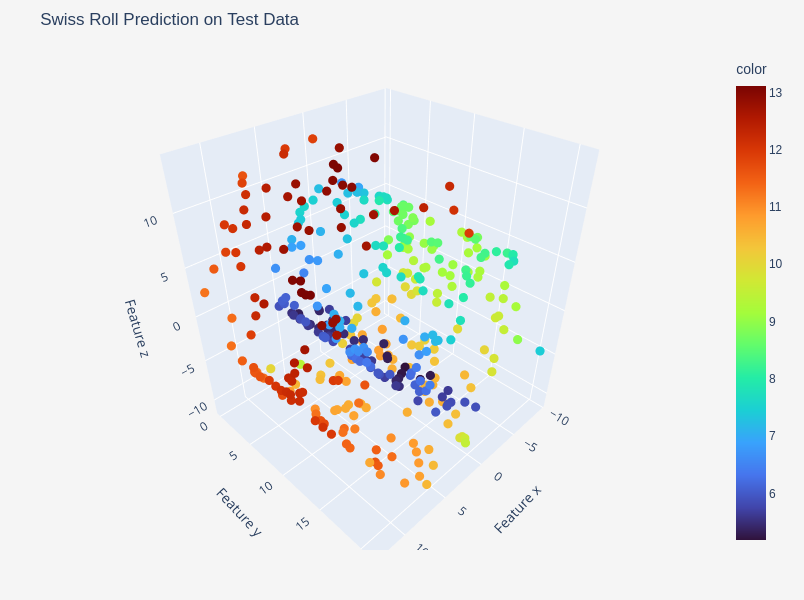

In [27]:
# Create an interactive 3D scatter plot, of the first two columns
fig = px.scatter_3d(x=X_org_tr[:, 0], y=X_org_tr[:, 1], z=X_org_tr[:, 2], 
                    title='Swiss Roll Prediction on Test Data',
                    labels={'x': 'Feature x', 
                            'y': 'Feature y', 
                            'z': 'Feature z'},
                    color=y_pred_org_tr_flat, 
                    color_continuous_scale = ply.colors.sequential.Turbo)
mrg = dict(l = 50, r = 50, b = 50, t = 50, pad = 10)
fig.update_traces(marker=dict(size=3, symbol='circle'))
fig.update_layout(width=600, height=600, margin = mrg, paper_bgcolor = 'whitesmoke')
fig.show()

---

## Write your observations here

- Challenge D
  - The only significant change to the notebook was to introduce data reuploading
    to the model, which significantly improves the predictions for the Swiss Roll data.

## Modifications (do not remove)
Under the [GPL-3.0](https://www.gnu.org/licenses/gpl-3.0.txt) license, if you perform any changes to this notebook, please list them here, adding a note with your name, contact details, date and changes to the code.

- [Jacob Cybulski](http://jacobcybulski.com) (2025, 1 April): The author of this notebook added this section to record all code changes
- [Jacob Cybulski](http://jacobcybulski.com) (2026, 2 October): Now also compatible with...<br>
  pennylane                 0.45.0<br>
  pennylane_lightning       0.45.0<br>
  torch                     2.11.0+cpu<br>
  torchaudio                2.11.0<br>
  torchvision               0.26.0+cpu<br>

## Software (Linux)

In [28]:
import os
os.system('pip list | grep -e pennylane -e torch');

pennylane                 0.45.0
pennylane_catalyst        0.15.0
pennylane_lightning       0.45.0
pennylane_lightning_gpu   0.45.0
torch                     2.11.0+cpu
torchaudio                2.11.0
torcheval                 0.0.7
torchmetrics              1.9.0
torchsummary              1.5.1
torchvision               0.26.0+cpu
